# Introduction

## Lab2: Train a Convolutional Neural Network (CNN).

In this Lab session we will learn how to train a CNN from scratch for classifying MNIST digits.

NOTE: All text cells starting with a number indicate that you have to write code or write a response. However, read all the cells to understand the full pipeline.

IMPORTANT: The goal is for you to learn how CNNs are implemented and trained with Pytorch. Using AI to write code for you harms this learning process, so it is strictly forbidden to use AI to write code. Feel free to use AI to _learn_ about Pytorch, CNNs, etc., but you are highly encouraged to read Pytorch's very good documentation, too. Concepts you learn in this assignment will be relevant for the exam.

In [10]:
# import necessary libraries
import torch
import torchvision
from torchvision import transforms as T
import torch.nn.functional as F

In [11]:
# This should return True if ROCm is working correctly
print("Is GPU available?", torch.cuda.is_available())

# This will print the name of your AMD graphics card
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Is GPU available? False


### 1. Define LeNet

![network architecture](https://www.researchgate.net/profile/Lucijano-Berus/publication/329891470/figure/fig1/AS:707347647307776@1545656229128/Architecture-of-LeNet-5-a-Convolutional-Neural-Network-for-digits-digits-recognition-An.ppm)

Here we are going to define our first CNN which is **LeNet** in this case. This architecture has been introduced and is detailed in [this article](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf). To construct a LeNet we will be using two convolutional layers followed by three fully-connected layers as indicated in the figure. The convolutional layers can be defined using `torch.nn.Conv2d` module of `torch.nn` package. Details can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Moreover, we will use a pooling operation to reduce the size of convolutional feature maps. For this case we are going to use `torch.nn.functional.max_pool2d`. Details about maxpooling can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.max_pool2d.html)

Differently from our previous Lab, we will use a Rectified Linear Units (ReLU) as activation function with the help of `torch.nn.functional.relu`, replacing `torch.nn.Sigmoid`. Details about ReLU can be found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.relu.html).

Note: The figure shows 32x32 input size while your data will be slightly differnt. You can either pad the input or adjust the network architecture slightly (as little as possible).

In [12]:
from matplotlib import use
import torch.nn as nn
class LeNet(torch.nn.Module):
  def __init__(self, use_sequential=True, dropout=0.0, in_channels=1):
    super(LeNet, self).__init__()
    self.classifier=None
    self.dropout=dropout

    pad=0 if in_channels==3 else 2
    
    if use_sequential:
      self.classifier=nn.Sequential(nn.Conv2d(in_channels,6,5,padding=pad),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                    nn.Conv2d(6,16,5),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                    nn.Flatten(),
                    nn.Linear(400,120),
                    nn.Dropout(p=dropout),
                    nn.Linear(120, 84),
                    nn.ReLU(),
                    nn.Dropout(p=dropout),
                    nn.Linear(84, 10))
    else:
      self.conv1=torch.nn.Conv2d(in_channels=in_channels, out_channels=6,kernel_size=5, stride=1, padding=pad)
      self.conv2=torch.nn.Conv2d(in_channels=6, out_channels=16,kernel_size=5, stride=1, padding=0)
      self.linear1=torch.nn.Linear(in_features=400, out_features=120)
      self.linear2=torch.nn.Linear(in_features=120, out_features=84)
      self.linear3=torch.nn.Linear(in_features=84, out_features=10)
      self.dropout = nn.Dropout(p=dropout)

  def forward(self, x):
    if not self.classifier:
      x = self.conv1(x)
      x = F.relu(x)
      x = F.max_pool2d(x, kernel_size=2)
      x = self.conv2(x)
      x = F.relu(x)
      x = F.max_pool2d(x, kernel_size=2)
      x = x.view(x.shape[0], -1)
      x = self.linear1(x)
      x = F.relu(x)
      x = self.dropout(x)
      x = self.linear2(x)
      x = F.relu(x)
      x = self.dropout(x)
      x = self.linear3(x)
    else:
      x=self.classifier(x)
    return x

### 2. Define cost function
Hint: Make sure to read the documentation of the loss function you use to validate that your network output matches what the loss expects as input.

In [13]:
def get_cost_function():
  cost_function = torch.nn.CrossEntropyLoss()
  return cost_function

### 3. Define the optimizer

We will use SGD with learning rate-lr, weight_decay=wd and  momentum=momentum

In [14]:
def get_optimizer(net, lr, wd, momentum):
  optimizer =  torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd, momentum=momentum)
  return optimizer

### Train and test functions

In [15]:
def test(net, data_loader, cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.

  net.eval() # Strictly needed if network contains layers which has different behaviours between train and test
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(data_loader):
      # Load data into GPU
      inputs = inputs.to(device)
      targets = targets.to(device)

      # Forward pass
      outputs = net(inputs)

      # Apply the loss
      loss = cost_function(outputs, targets)

      # Better print something
      samples+=inputs.shape[0]
      cumulative_loss += loss.item() # Note: the .item() is needed to extract scalars from tensors
      _, predicted = outputs.max(1)
      cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100


def train(net,data_loader,optimizer,cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.


  net.train() # Strictly needed if network contains layers which has different behaviours between train and test
  for batch_idx, (inputs, targets) in enumerate(data_loader):
    # Load data into GPU
    inputs = inputs.to(device)
    targets = targets.to(device)

    # Forward pass
    outputs = net(inputs)

    # Apply the loss
    loss = cost_function(outputs,targets)

    # Reset the optimizer
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    # Better print something, no?
    samples+=inputs.shape[0]
    cumulative_loss += loss.item()  #item() convert numerical value of the tensor into a float (allows to not store graphs calcul of the error that is stocked in the loss tensor)
    _, predicted = outputs.max(1) #.max(1) returns the max value on the dim 1 and returns the proba and the index( we just stock the index)
    cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100

### Define the function that fetches a data loader that is then used during iterative training.

We will learn a new thing in this function as how to Normalize the inputs given to the network.

***Why Normalization is needed***?

To have nice and stable training of the network it is recommended to normalize the network inputs between \[-1, 1\].

***How it can be done***?

This can be simply done using `torchvision.transforms.Normalize()` transform. Details can be found [here](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html).

In [16]:
def get_data(batch_size, test_batch_size=256,dataset='mnist', use_data_augmentation=False):
  dataset=dataset.lower()
  # Prepare data transformations and then combine them sequentially
  transform = list()

  if dataset == 'mnist':
    transform = T.Compose([
      T.ToTensor(),
      T.Normalize(mean=[0.5], std=[0.5]),
    ])

    full_training_data = torchvision.datasets.MNIST('./data', train=True, transform=transform, download=True)
    test_data = torchvision.datasets.MNIST('./data', train=False, transform=transform, download=True)

    num_samples = len(full_training_data)
    training_samples = int(num_samples * 0.5 + 1)
    validation_samples = num_samples - training_samples
    training_data, validation_data = torch.utils.data.random_split(
      full_training_data, [training_samples, validation_samples]
    )

  elif dataset == 'cifar10':
    train_transforms = []
    if use_data_augmentation:
      train_transforms += [
        T.RandomHorizontalFlip(p=0.5),
        # Keep crops gentle for a small 32x32 image
        T.RandomCrop(size=32, padding=2), 
      ]
    train_transforms += [
      T.ToTensor(),
      # Update normalization for 3 channels (RGB)
      T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), 
    ]
    train_transforms = T.Compose(train_transforms)

    test_transforms = T.Compose([
      T.ToTensor(),
      T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    # train avec augmentation, val/test sans augmentation
    full_train_aug = torchvision.datasets.CIFAR10('./data', train=True, transform=train_transforms, download=True)
    full_train_eval = torchvision.datasets.CIFAR10('./data', train=True, transform=test_transforms, download=True)
    test_data = torchvision.datasets.CIFAR10('./data', train=False, transform=test_transforms, download=True)

    num_samples = len(full_train_aug)
    training_samples = int(num_samples * 0.5 + 1)
    validation_samples = num_samples - training_samples

    perm = torch.randperm(num_samples)
    train_idx = perm[:training_samples]
    val_idx = perm[training_samples:]

    training_data = torch.utils.data.Subset(full_train_aug, train_idx)
    validation_data = torch.utils.data.Subset(full_train_eval, val_idx)

  else:
    raise ValueError("dataset must be 'mnist' or 'cifar10'")

  train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True)
  val_loader = torch.utils.data.DataLoader(validation_data, batch_size=test_batch_size, shuffle=False)
  test_loader = torch.utils.data.DataLoader(test_data, batch_size=test_batch_size, shuffle=False)

  return train_loader, val_loader, test_loader

### 4. Initializing model and wrapping everything up

Finally, we need a main function which initializes everything + the needed hyperparameters and loops over multiple epochs (printing the results).

In [17]:
'''
Input arguments
  batch_size: Size of a mini-batch
  device: GPU where you want to train your network
  weight_decay: Weight decay co-efficient for regularization of weights
  momentum: Momentum for SGD optimizer
  epochs: Number of epochs for training the network
'''

def main(batch_size=128,
         device=None,
         learning_rate=0.01,
         weight_decay=0.000001,
         momentum=0.9,
         epochs=50,
         use_sequential=True,
         early_stopping_patience=None,
         early_stopping_min_delta=0.0,
         dataset='mnist',
         use_data_augmentation=False,
         dropout=0.0,
         in_channels=1):

  if device is None:
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

  train_loader, val_loader, test_loader = get_data(batch_size, dataset=dataset, use_data_augmentation=use_data_augmentation)

  # Define LeNet-5 and move it to the selected device
  net = LeNet(use_sequential=use_sequential, dropout=dropout, in_channels=in_channels).to(device)

  optimizer = get_optimizer(net, learning_rate, weight_decay, momentum)

  cost_function = get_cost_function()

  print(f'Using device: {device}')
  print('Before training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function, device=device)
  val_loss, val_accuracy = test(net, val_loader, cost_function, device=device)
  test_loss, test_accuracy = test(net, test_loader, cost_function, device=device)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  best_val_loss = float('inf')
  epochs_without_improvement = 0

  for e in range(epochs):
    train_loss, train_accuracy = train(net, train_loader, optimizer, cost_function, device=device)
    val_loss, val_accuracy = test(net, val_loader, cost_function, device=device)
    print('Epoch: {:d}'.format(e + 1))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
    print('-----------------------------------------------------')

    improved = val_loss < (best_val_loss - early_stopping_min_delta)
    if improved:
      best_val_loss = val_loss
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
      print(f"Early stopping at epoch {e+1} (no val-loss improvement for {early_stopping_patience} epochs).")
      break

  print('After training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function, device=device)
  val_loss, val_accuracy = test(net, val_loader, cost_function, device=device)
  test_loss, test_accuracy = test(net, test_loader, cost_function, device=device)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  return net, test_loader

Lets train!

In [18]:
net, test_loader = main(use_sequential=False)

Using device: cpu
Before training:


	 Training loss 0.01805, Training accuracy 10.02
	 Validation loss 0.00907, Validation accuracy 9.81
	 Test loss 0.00922, Test accuracy 10.35
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00869, Training accuracy 63.68
	 Validation loss 0.00095, Validation accuracy 92.44
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00120, Training accuracy 95.24
	 Validation loss 0.00050, Validation accuracy 96.17
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00075, Training accuracy 97.14
	 Validation loss 0.00032, Validation accuracy 97.39
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00056, Training accuracy 97.75
	 Validation loss 0.00041, Validation accuracy 96.75
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00044, Training accuracy 98.15
	 Validation loss 0.00030, Validation accuracy 97.57
---------------------------------

#### Optional: Plot the training and validation curves.



### 5. Plot a confusion matrix to check which MNIST digit is most frequently confused with which other digit. Can you explain why?



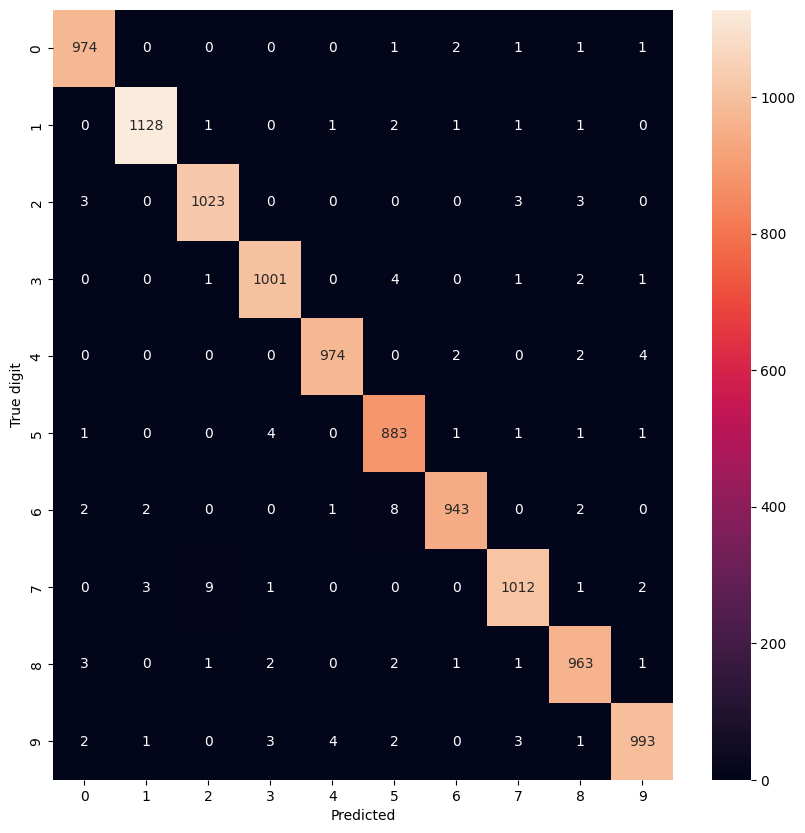

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(net,test_loader,device=None):
    
    if device is None:
      device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    net.eval()
    y_pred = []
    y_true = []

    # get all predictions
    with torch.no_grad():
      for inputs, targets in test_loader:
        inputs=inputs.to(device)
        targets=targets.to(device)
        outputs=net(inputs)
        _, predicted=outputs.max(1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(targets.cpu().numpy())

    cm=confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,10))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.ylabel('True digit')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion_matrix(net, test_loader)

The most often confused digits here are:
4 & 9 and 3 & 5. It can be explained by the fact that leNet learn from forms so if 2 digits have the same topology they may have chances to be confused.


### For the remaining tasks try to integrate the changes in the code above while avoiding duplicate code as much as possible. For every task, introduce flags (i.e., function arguments) to the main() function to enable the new functionality of the task. It should always be possible to run the original implementation above. Finally, call the main function with the correct flags for each task in the cells below.

### 6. The LeNet5 architecture can also be implemented using the sequential API ([see documentation](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)). Reimplement it with this API and run training + evaluation once to verify it works.

In [20]:
main(use_sequential=True)

Using device: cpu
Before training:
	 Training loss 0.01807, Training accuracy 9.84
	 Validation loss 0.00907, Validation accuracy 10.10
	 Test loss 0.00922, Test accuracy 9.95
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00860, Training accuracy 64.53
	 Validation loss 0.00079, Validation accuracy 94.14
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00114, Training accuracy 95.43
	 Validation loss 0.00055, Validation accuracy 95.69
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00070, Training accuracy 97.13
	 Validation loss 0.00033, Validation accuracy 97.41
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00055, Training accuracy 97.87
	 Validation loss 0.00026, Validation accuracy 97.97
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00043, Training accuracy 98.25
	 Validation loss 0.00025, Validation accuracy 98.07

(LeNet(
   (classifier): Sequential(
     (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
     (4): ReLU()
     (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (6): Flatten(start_dim=1, end_dim=-1)
     (7): Linear(in_features=400, out_features=120, bias=True)
     (8): Dropout(p=0.0, inplace=False)
     (9): Linear(in_features=120, out_features=84, bias=True)
     (10): ReLU()
     (11): Dropout(p=0.0, inplace=False)
     (12): Linear(in_features=84, out_features=10, bias=True)
   )
 ),
 <torch.utils.data.dataloader.DataLoader at 0x7f17e9b842f0>)

### 7. Implement adaptive early stopping: if the validation loss did not decrease for K consecutive epochs, stop training.
#### Optional: Select the model based on the best validation loss.

In [21]:
#the model with the best validation loss here is with use_sequential=False
net, test_loader = main(use_sequential=False, early_stopping_patience=5)

Using device: cpu
Before training:
	 Training loss 0.01804, Training accuracy 10.57
	 Validation loss 0.00906, Validation accuracy 10.83
	 Test loss 0.00921, Test accuracy 10.31
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00920, Training accuracy 62.20
	 Validation loss 0.00088, Validation accuracy 93.11
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00113, Training accuracy 95.57
	 Validation loss 0.00043, Validation accuracy 96.63
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00073, Training accuracy 97.04
	 Validation loss 0.00033, Validation accuracy 97.25
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00056, Training accuracy 97.71
	 Validation loss 0.00030, Validation accuracy 97.65
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00045, Training accuracy 98.13
	 Validation loss 0.00025, Validation accuracy 98.

### 8. Change the dataset in order to train and evaluate the LeNet5 network on [CIFAR10](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html).

In [22]:
net, text_loader = main(use_sequential=False, dataset='cifar10',in_channels=3)

/home/elkou/TP/.venvtp/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using device: cpu
Before training:
	 Training loss 0.01808, Training accuracy 9.77
	 Validation loss 0.00904, Validation accuracy 9.58
	 Test loss 0.00922, Test accuracy 9.61
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01728, Training accuracy 18.32
	 Validation loss 0.00786, Validation accuracy 26.82
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01435, Training accuracy 33.16
	 Validation loss 0.00697, Validation accuracy 35.74
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01243, Training accuracy 42.31
	 Validation loss 0.00585, Validation accuracy 45.50
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01159, Training accuracy 45.95
	 Validation loss 0.00569, Validation accuracy 47.59
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01090, Training accuracy 49.49
	 Validation loss 0.00544, Validation accuracy 49.76


### 9. Try to improve the performance on CIFAR10 with both:
   *   data-augmentation
   *   dropout

In [23]:
net, test_loader = main(dataset='cifar10', use_sequential=False,in_channels=3, use_data_augmentation=True, dropout=0.3)

Using device: cpu
Before training:
	 Training loss 0.01808, Training accuracy 10.24
	 Validation loss 0.00904, Validation accuracy 9.76
	 Test loss 0.00923, Test accuracy 10.00
-----------------------------------------------------
Epoch: 1
	 Training loss 0.01785, Training accuracy 13.62
	 Validation loss 0.00854, Validation accuracy 18.92
-----------------------------------------------------
Epoch: 2
	 Training loss 0.01628, Training accuracy 23.44
	 Validation loss 0.00756, Validation accuracy 28.79
-----------------------------------------------------
Epoch: 3
	 Training loss 0.01471, Training accuracy 29.27
	 Validation loss 0.00681, Validation accuracy 35.79
-----------------------------------------------------
Epoch: 4
	 Training loss 0.01352, Training accuracy 35.63
	 Validation loss 0.00625, Validation accuracy 41.69
-----------------------------------------------------
Epoch: 5
	 Training loss 0.01283, Training accuracy 39.76
	 Validation loss 0.00622, Validation accuracy 42.2

### 10. Use the ResNet18 class from Pytorch to train and evaluate a ResNet on CIFAR10 (make sure it works, but if it takes too long, you don't have to train until convergence).

In [24]:
from torchvision.models import resnet18
import torch.nn as nn

def get_cifar10_data_resnet(batch_size=128, test_batch_size=256):
  mean = [0.4914, 0.4822, 0.4465]
  std = [0.2470, 0.2435, 0.2616]

  train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
  ])

  eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
  ])

  train_aug = torchvision.datasets.CIFAR10('./data', train=True, transform=train_transform, download=True)
  train_eval = torchvision.datasets.CIFAR10('./data', train=True, transform=eval_transform, download=True)
  test_data = torchvision.datasets.CIFAR10('./data', train=False, transform=eval_transform, download=True)

  n = len(train_aug)  # 50000
  idx = torch.randperm(n)
  split = 45000
  train_idx, val_idx = idx[:split], idx[split:]

  train_data = torch.utils.data.Subset(train_aug, train_idx)
  val_data = torch.utils.data.Subset(train_eval, val_idx)

  train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
  val_loader = torch.utils.data.DataLoader(val_data, batch_size=test_batch_size, shuffle=False, num_workers=2)
  test_loader = torch.utils.data.DataLoader(test_data, batch_size=test_batch_size, shuffle=False, num_workers=2)

  return train_loader, val_loader, test_loader


def main_resnet18_cifar10(batch_size=128, lr=0.1, wd=5e-4, momentum=0.9, epochs=5, device=None):
  if device is None:
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

  train_loader, val_loader, test_loader = get_cifar10_data_resnet(batch_size=batch_size)

  net = resnet18(weights=None, num_classes=10)
  # CIFAR10-friendly stem
  net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
  net.maxpool = nn.Identity()
  net = net.to(device)

  optimizer = torch.optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
  cost_function = torch.nn.CrossEntropyLoss()

  for e in range(epochs):
    train_loss, train_acc = train(net, train_loader, optimizer, cost_function, device=device)
    val_loss, val_acc = test(net, val_loader, cost_function, device=device)
    print(f"Epoch {e+1}/{epochs} | train loss {train_loss:.5f} acc {train_acc:.2f} | val loss {val_loss:.5f} acc {val_acc:.2f}")

  test_loss, test_acc = test(net, test_loader, cost_function, device=device)
  print(f"Test loss {test_loss:.5f} | Test acc {test_acc:.2f}")

  return net, test_loader

# Run question 10
resnet_net, resnet_test_loader = main_resnet18_cifar10(epochs=5)

KeyboardInterrupt: 

too long to compile again but i did it once and got:

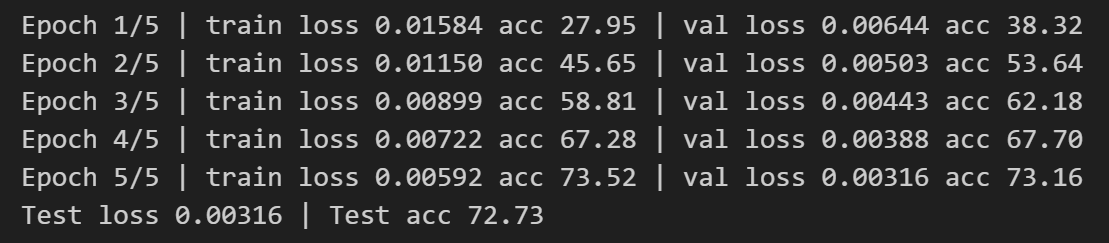